**Acropora tenuis spp in the central Philippines - isolation by distance within cryptic taxa**\

_Inputs:_\
Metadata with lat/lons of sampling locations\
SNP data from each cryptic taxon in genind format\
_Outputs:_\
Fst and linearized Fst between each pair of sites\
Great circle distances between each pair of sites\
Linear regressions and Mantel tests\
Figures\
Created by Jaelyn Bos, November 2024

In [1]:
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")
#.libPaths('/hb/software/apps/r/conda3-4.4.1/lib/R/library')
#.libPaths('/hb/home/jbos/R/x86_64-conda-linux-gnu-library/4.4')

In [2]:
#Load required packages
library(adegenet)
library(hierfstat)
library(tidyverse)
library(vegan)
library(vcfR)
library(sp)
library(sf)
library(cowplot)

Loading required package: ade4


   /// adegenet 2.1.11 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()




Attaching package: ‘hierfstat’


The following objects are masked from ‘package:adegenet’:

    Hs, read.fstat


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8


   *****       ***   vcfR   ***       *****
   This is vcfR 1

In [3]:
#Input: site string
#Output: island tag
island_sel <- function(string){
  x<-substr(string, start = 1, stop = 3)
  return(x)
}

In [4]:
#Inputs: wide form FSTs and dataframe of individuals corresponding to each population
#Output: long form FSTs. Columns: siteA	siteB	fst	siteA_counts	siteB_counts	mean_counts
fst_transform<-function(fsts,indpops){
    fst_long<-pivot_longer(fsts,cols=colnames(fsts)[2:length(colnames(fsts))],names_to='siteB',values_to='fst')
    colnames(fst_long)<-c('siteA','siteB','fst')
    fst_long<-fst_long[!is.nan(fst_long$fst),]
    dum<-as.data.frame(table(indpops$Population))
    colnames(dum)<-c('siteA','siteA_counts')
    fst_long<-left_join(fst_long,dum,by='siteA')
    colnames(dum)<-c('siteB','siteB_counts')
    fst_long<-left_join(fst_long,dum,by='siteB')
    fst_long$mean_counts<-rowMeans(as.data.frame(cbind(fst_long$siteA_counts,fst_long$siteB_counts)))
    return(fst_long)
}

In [5]:
#Input: FSTs, vector of number of individuals per population, minimum number of individuals per popualtion
#Output: Matrix of FSTs including only populations above the minimum size
fst_trim_by_N<-function(fsts,inds_per_pop,min_n){
    fsts<-as.data.frame(fsts)
    fst_trim<-fsts[fsts$...1 %in% as.data.frame(table(inds_per_pop$Population)[table(inds_per_pop$Population)>(min_n-1)])$Var1,]
    fst_trim<-fst_trim[,colnames(fst_trim)%in% as.data.frame(table(inds_per_pop$Population)[table(inds_per_pop$Population)>(min_n-1)])$Var1]
    rownames(fst_trim)<-colnames(fst_trim)
    return(fst_trim)
    }

In [6]:
#Inputs: wide form FSTs
#Outputs: wide form linearized FSTs for Mantel test
linear_fsts<-function(wide_fsts){
  wide_fsts<-as.data.frame(wide_fsts)
  rownames(wide_fsts)<-wide_fsts$...1
  wide_fsts<-wide_fsts[,-1]
  fst_lin <- wide_fsts/(1-wide_fsts)
  return(fst_lin)
}

linear_fsts2<-function(wide_fsts){
  wide_fsts<-as.data.frame(wide_fsts)
  fst_lin <- wide_fsts/(1-wide_fsts)
  return(fst_lin)
}

In [7]:
#Count number of individual per population
make_counts<-function(inds_per_pop){
    dummy<-as.data.frame(matrix(nrow=length(unique(inds_per_pop$Population))))
    dummy[,1]<-unique(inds_per_pop$Population)
    dummy[,2]<-table(inds_per_pop$Population)
    colnames(dummy)<-c('pop','count')
    return(dummy)
    }

In [8]:
#Creates appropriate row names for site distance matrix: this is important for running Mantel tests
rnam<-function(d){
    rownames(d)<-d$X
    d<-d[,-1]
    return(d)
    }

In [9]:
#Inputs: wide form linearized FSTs and wide form distances for each cryptic taxon
#Outputs: long form dataframe with columns SiteA	SiteB	Lin_FST	Distance_m
fst_dist_join<-function(fsts_linear, distances){
    fsts_linear$SiteA<-rownames(fsts_linear)
    distances$SiteA<-rownames(distances)
    fst_lin_lon<-pivot_longer(data=fsts_linear,cols=colnames(fsts_linear)[!(colnames(fsts_linear) %in% 'SiteA')],names_to='SiteB',values_to='Lin_FST')
    dists_lon<-pivot_longer(data=distances,cols=colnames(distances)[!(colnames(distances) %in% 'SiteA')],names_to='SiteB',values_to='Distance_m')
    mer<-inner_join(fst_lin_lon,dists_lon)
    mer<-mer[mer$SiteA!=mer$SiteB,]
    mer$Distance_m<-as.numeric(mer$Distance_m)
    mer_uniquerows <- mer %>% distinct(Distance_m, .keep_all = TRUE)
    return(mer_uniquerows)
    }

In [10]:
#Calculate great circle distances from lat/lons
wide_dists <- function(sites){
    x<-st_as_sf(sites,coords=c('LONGITUDE','LATITUDE'))
    x<-st_set_crs(x,4326)
    d <- st_distance(x)
    colnames(d)<-sites$Name
    rownames(d)<-sites$Name
    d<-as.data.frame(d)
    return(d)
}

In [11]:
#Stick together datasets for figure making
join_for_fig<-function(merged_data,long_fsts){
    merged_data$SiteAB<-paste(merged_data$SiteA,merged_data$SiteB)
    long_fsts$SiteAB<-paste(long_fsts$siteA,long_fsts$siteB)
    new<-left_join(merged_data,long_fsts,by='SiteAB')
    new$Distance_km<-new$Distance_m/1000
    new<-new[,c('SiteA','SiteB','Lin_FST','Distance_m','mean_counts','Distance_km')]
    return(new)
    }

In [12]:
#Import site locations with lat/lons
sites <- read.csv('all_Atenuis_sites_FIXED.csv')
metadat<-read.csv('metadata_shoredist.csv')

Import data in vcf form. VCFs are filtered SNPs for each cryptic taxon

In [13]:
#Import SNPs for each cryptic taxon
setwd('/scratch/jbos/')
spp1<-read.vcfR("spp1_copy/pruned_snps.vcf")
spp2<-read.vcfR("spp2_copy/pruned_snps.vcf")
spp3<-read.vcfR("spp3_copy/pruned_snps.vcf")
spp4<-read.vcfR("spp4_copy/pruned_snps.vcf")
spp0<-read.vcfR("combined_snps_copy/pruned_snps.vcf")

Scanning file to determine attributes.
File attributes:
  meta lines: 361
  header_line: 362
  variant count: 2308
  column count: 125
Meta line 361 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 2308
  Character matrix gt cols: 125
  skip: 0
  nrows: 2308
  row_num: 0
Processed variant: 2308
All variants processed
Scanning file to determine attributes.
File attributes:
  meta lines: 339
  header_line: 340
  variant count: 1689
  column count: 78
Meta line 339 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 1689
  Character matrix gt cols: 78
  skip: 0
  nrows: 1689
  row_num: 0
Processed variant: 1689
All variants processed
Scanning file to determine attributes.
File attributes:
  meta lines: 313
  header_line: 314
  variant count: 1221
  column count: 66
Meta line 313 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt create

In [14]:
#Convert VCF files to genind
genind1 <- vcfR2genind(spp1)
genind2 <- vcfR2genind(spp2)
genind3 <- vcfR2genind(spp3)
genind4 <- vcfR2genind(spp4)
genind0 <- vcfR2genind(spp0)

In [15]:
#Get lists of individuals for each cryptic taxon
taxa1_inds<-rownames(genind1@tab)
taxa2_inds<-rownames(genind2@tab)
taxa3_inds<-rownames(genind3@tab)
taxa4_inds<-rownames(genind4@tab)
taxa0_inds<-rownames(genind0@tab)

In [16]:
#Make taxon 4 dataset without parent/offspring triad
genind4b<-genind4[!(indNames(genind4) %in% c('CEB01_T12'))]

In [17]:
#Write lists of individuals in each cryptic taxon to CSV
setwd('/hb/home/jbos/')

write.csv(taxa1_inds,'taxa1_inds_copy.csv')
write.csv(taxa2_inds,'taxa2_inds_copy.csv')
write.csv(taxa3_inds,'taxa3_inds_copy.csv')
write.csv(taxa4_inds,'taxa4_inds_copy.csv')

In [18]:
#Create individual lat/lons (by sampling site) dataset with variable for taxon
ind_latlons<-as.data.frame(taxa0_inds)
colnames(ind_latlons)<-'Sample_ID'
ind_latlons$Name<-unlist(lapply(strsplit(ind_latlons$Sample_ID,"_"), head, 1))
ind_latlons<-left_join(ind_latlons,sites)

ind_latlons$taxa<-0
ind_latlons$taxa[ind_latlons$Sample_ID %in% taxa1_inds]<-1
ind_latlons$taxa[ind_latlons$Sample_ID %in% taxa2_inds]<-2
ind_latlons$taxa[ind_latlons$Sample_ID %in% taxa3_inds]<-3
ind_latlons$taxa[ind_latlons$Sample_ID %in% taxa4_inds]<-4

Joining with `by = join_by(Name)`


In [19]:
#Median latitude by taxon
median(ind_latlons$LATITUDE[ind_latlons$taxa==1])
median(ind_latlons$LATITUDE[ind_latlons$taxa==2])
median(ind_latlons$LATITUDE[ind_latlons$taxa==3])
median(ind_latlons$LATITUDE[ind_latlons$taxa==4])

[1] 10.50607

[1] 10.5915

[1] 10.0039

[1] 10.2396

In [20]:
#Kruskal Wallis test for latitude by group
kruskal.test(LATITUDE ~ taxa, data = ind_latlons)
nrow(ind_latlons)


	Kruskal-Wallis rank sum test

data:  LATITUDE by taxa
Kruskal-Wallis chi-squared = 21.364, df = 4, p-value = 0.0002682


[1] 301

In [21]:
#Create combined metadata including both site and individual (from GPS track) lat lons
metadat<-left_join(ind_latlons,metadat)
metadat<-metadat[,-which(names(metadat) %in% c('X','Unnamed..0','Unnamed..6','Unnamed..7','DisplayColor','ele','time'))]
colnames(metadat)

Joining with `by = join_by(Sample_ID)`


[1] "Sample_ID" "Name"      "LONGITUDE" "LATITUDE"  "taxa"      "Time"     
 [7] "Day"       "Month"     "Year"      "Depth_ft"  "hour"      "minute"   
[13] "dt"        "lat"       "lon"       "name"      "Distance"  "SHOREDIST"

In [22]:
#Kruskal Wallis test for depth by group
kruskal.test(Depth_ft ~ taxa, data = metadat)
table(metadat$Depth_ft>0)


	Kruskal-Wallis rank sum test

data:  Depth_ft by taxa
Kruskal-Wallis chi-squared = 7.0339, df = 3, p-value = 0.07083



TRUE 
  97 

In [23]:
#Kruskal Wallis test for distance to shore by group
kruskal.test(SHOREDIST ~ taxa, data = metadat)


	Kruskal-Wallis rank sum test

data:  SHOREDIST by taxa
Kruskal-Wallis chi-squared = 5.0155, df = 4, p-value = 0.2857


In [24]:
#Add population factors to each genind. Here, we define a sampling site as a population
genind1@pop <-as.factor(unlist(lapply(strsplit(rownames(genind1$tab),"_"), head, 1)))
genind2@pop <-as.factor(unlist(lapply(strsplit(rownames(genind2$tab),"_"), head, 1)))
genind3@pop <-as.factor(unlist(lapply(strsplit(rownames(genind3$tab),"_"), head, 1)))
genind4@pop <-as.factor(unlist(lapply(strsplit(rownames(genind4$tab),"_"), head, 1)))
genind0@pop <-as.factor(unlist(lapply(strsplit(rownames(genind0$tab),"_"), head, 1)))

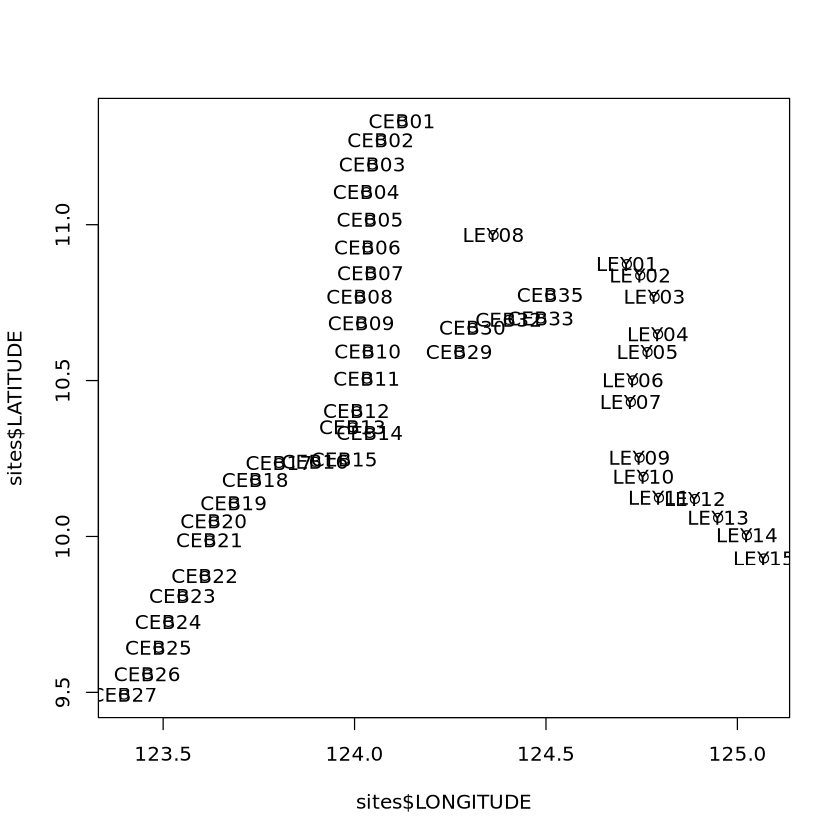

In [25]:
#Plot site names by lat/lon as a sanity check
plot(sites$LONGITUDE, sites$LATITUDE,text(sites$LONGITUDE, sites$LATITUDE,sites$Name))

In [25]:
#For each taxon, keep only sites including at least one individual from that taxon
sites1<-sites[sites$Name %in% unique(genind1@pop),]
sites2<-sites[sites$Name %in% unique(genind2@pop),]
sites3<-sites[sites$Name %in% unique(genind3@pop),]
sites4<-sites[sites$Name %in% unique(genind4@pop),]
sites0<-sites[sites$Name %in% unique(genind0@pop),]

In [26]:
#Convert genind to hierfstat form to calculate FSTs
hstat1<-genind2hierfstat(genind1,pop=genind1@pop)
hstat2<-genind2hierfstat(genind2,pop=genind2@pop)
hstat3<-genind2hierfstat(genind3,pop=genind3@pop)
hstat4<-genind2hierfstat(genind4,pop=genind4@pop)
hstat0<-genind2hierfstat(genind0,pop=genind0@pop)

In [27]:
#Do all this for taxon 4 sensitivity test
genind4b@pop <-as.factor(unlist(lapply(strsplit(rownames(genind4b$tab),"_"), head, 1)))
sites4b<-sites[sites$Name %in% unique(genind4b@pop),]
hstat4b<-genind2hierfstat(genind4b,pop=genind4b@pop)
dists4b<-wide_dists(sites4b)

In [28]:
#Make wide form dataframes of distance between sites
dists1<-wide_dists(sites1)
dists2<-wide_dists(sites2)
dists3<-wide_dists(sites3)
dists4<-wide_dists(sites4)
dists0<-wide_dists(sites0)

In [29]:
#Take log of distances for Mantel tests
log_dists1<-log(dists1)
log_dists2<-log(dists2)
log_dists3<-log(dists3)
log_dists4<-log(dists4)
log_dists0<-log(dists0)

In [30]:
#Make sf object out of points(this will be useful later)
sites_sf<-st_as_sf(sites,coords=c('LONGITUDE','LATITUDE'))
sites_sf<-st_set_crs(sites_sf,4326)
sitepoints<-st_combine(sites_sf)
sites_proj<-st_transform(sitepoints,crs=9834)

In [31]:
#Calculate pairwise FSTs with confidence intervals within each cryptic taxon
#fst_1<-pairwise.WCfst(hstat1)
#fst_2<-pairwise.WCfst(hstat2)
#fst_3<-pairwise.WCfst(hstat3)
#fst_4<-pairwise.WCfst(hstat4)
#fst_all<-pairwise.WCfst(hstat0)

In [31]:
#Same for taxon 4 sensitivity test
#fst_4b<-pairwise.WCfst(hstat4b)
#write.csv(fst_4b,'fst_4b_pruned.csv',row.names=TRUE)

In [48]:
#Write pairwise FSTs to FST
#write.csv(fst_1,'fst_1_pruned.csv',row.names=TRUE)
#write.csv(fst_2,'fst_2_pruned.csv',row.names=TRUE)
#write.csv(fst_3,'fst_3_pruned.csv',row.names=TRUE)
#write.csv(fst_4,'fst_4_pruned.csv',row.names=TRUE)
#write.csv(fst_all,'fst_all_pruned.csv',row.names=TRUE)

In [32]:
#Alternatively, read in pairwise FSTs from csv
fst1<-read_csv('fst_1_pruned.csv',show_col_types = FALSE)
fst2<-read_csv('fst_2_pruned.csv',show_col_types = FALSE)
fst3<-read_csv('fst_3_pruned.csv',show_col_types = FALSE)
fst4<-read_csv('fst_4_pruned.csv',show_col_types = FALSE)
fstall<-read_csv('fst_all_pruned.csv',show_col_types = FALSE)

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [34]:
#Make dataframes of individuals and corresponding populations for each taxon
inds_per_pop1<-as.data.frame(cbind(rownames(genind1@tab),as.character(genind1@pop)))
colnames(inds_per_pop1)<-c("Individual","Population")

inds_per_pop2<-as.data.frame(cbind(rownames(genind2@tab),as.character(genind2@pop)))
colnames(inds_per_pop2)<-c("Individual","Population")

inds_per_pop3<-as.data.frame(cbind(rownames(genind3@tab),as.character(genind3@pop)))
colnames(inds_per_pop3)<-c("Individual","Population")

inds_per_pop4<-as.data.frame(cbind(rownames(genind4@tab),as.character(genind4@pop)))
colnames(inds_per_pop4)<-c("Individual","Population")

inds_per_pop0<-as.data.frame(cbind(rownames(genind0@tab),as.character(genind0@pop)))
colnames(inds_per_pop0)<-c("Individual","Population")

In [35]:
#Make site counts dataframe to count individuals per taxon per site
c1<-make_counts(inds_per_pop1)
c2<-make_counts(inds_per_pop2)
c3<-make_counts(inds_per_pop3)
c4<-make_counts(inds_per_pop4)

site_counts<-full_join(c1,c2,by='pop')
site_counts<-full_join(site_counts,c3,by='pop')
site_counts<-full_join(site_counts,c4,by='pop')
colnames(site_counts)<-c('pop','taxon1','taxon2','taxon3','taxon4')
site_counts[is.na(site_counts)] <- 0
write.csv(site_counts,'site_counts.csv')

In [36]:
#Taxa 4 sensitivity cont'd 
fst4b<-read_csv('fst_4b_pruned.csv',show_col_types = FALSE)
inds_per_pop4b<-as.data.frame(cbind(rownames(genind4b@tab),as.character(genind4b@pop)))
colnames(inds_per_pop4b)<-c("Individual","Population")

New names:
• `` -> `...1`


In [37]:
#Transform FSTs to long form and add variables for number of individuals in each population
fst1_long<-fst_transform(fst1,inds_per_pop1)
fst1_long_trim<-fst1_long[(fst1_long$siteA_counts>1 & fst1_long$siteB_counts>1),]

fst2_long<-fst_transform(fst2,inds_per_pop2)
fst2_long_trim<-fst2_long[(fst2_long$siteA_counts>1 & fst2_long$siteB_counts>1),]

fst3_long<-fst_transform(fst3,inds_per_pop3)
fst3_long_trim<-fst3_long[(fst3_long$siteA_counts>1 & fst3_long$siteB_counts>1),]

fst4_long<-fst_transform(fst4,inds_per_pop4)
fst4_long_trim<-fst4_long[(fst4_long$siteA_counts>1 & fst4_long$siteB_counts>1),]

fst0_long<-fst_transform(fstall,inds_per_pop0)

fst4b_long<-fst_transform(fst4b,inds_per_pop4b)
fst4b_long_trim<-fst4b_long[(fst4b_long$siteA_counts>1 & fst4b_long$siteB_counts>1),]

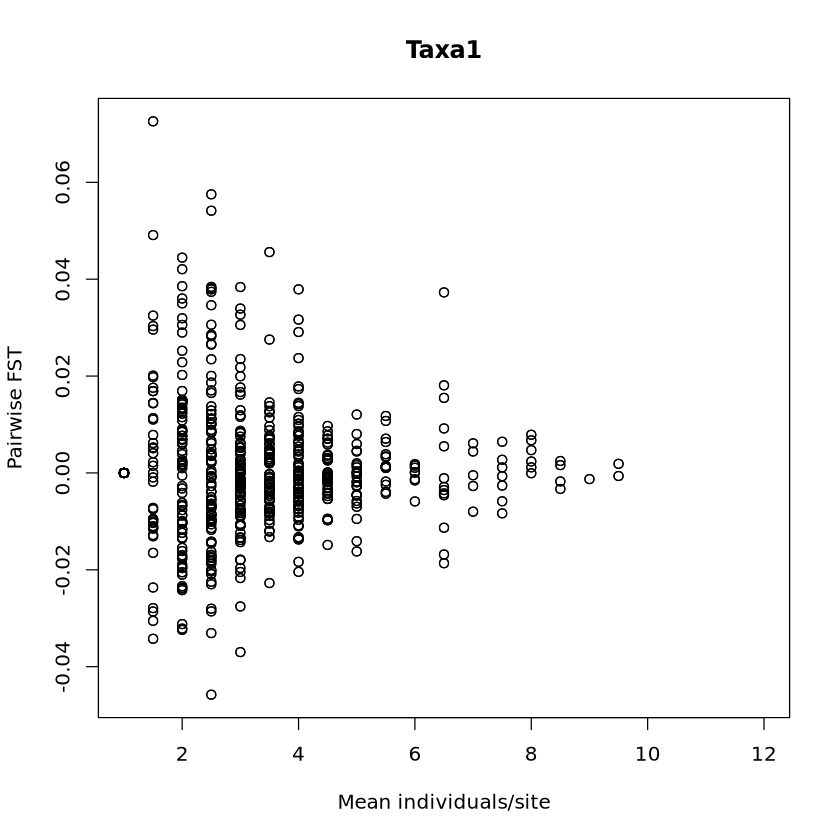

In [54]:
#Plot pairwise FSTs vs. individuals/site. This is a nice check to see if high FSTs are mostly or purely due to having few individuals per site
plot(fst1_long$mean_counts,fst1_long$fst,main="Taxa1",xlab="Mean individuals/site",ylab="Pairwise FST")

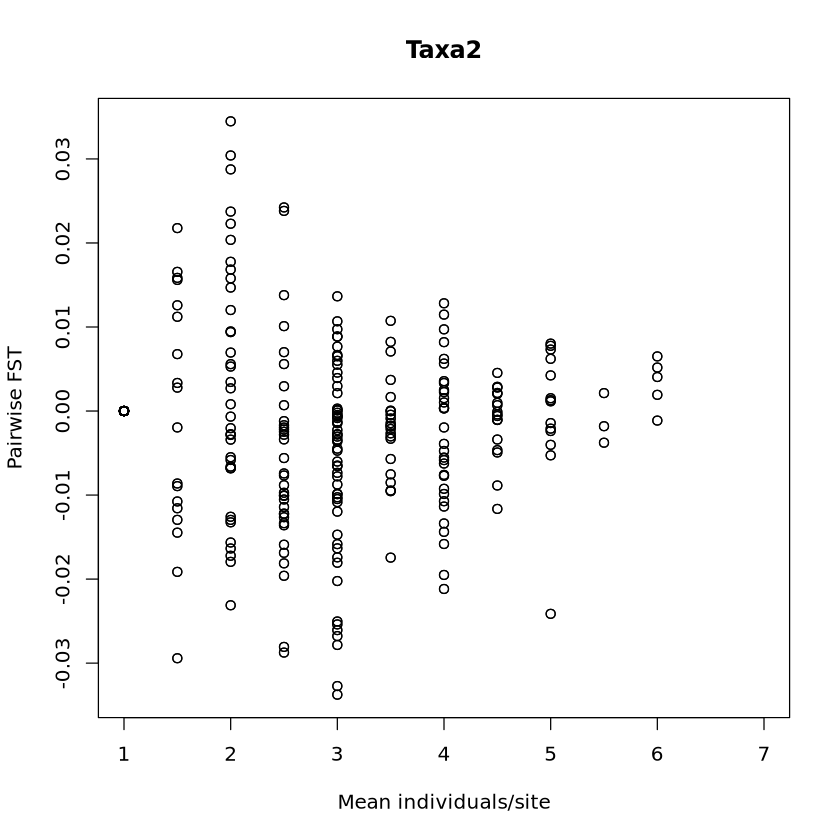

In [55]:
#Plot pairwise FSTs vs. individuals/site. This is a nice check to see if high FSTs are mostly or purely due to having few individuals per site
plot(fst2_long$mean_counts,fst2_long$fst,main="Taxa2",xlab="Mean individuals/site",ylab="Pairwise FST")

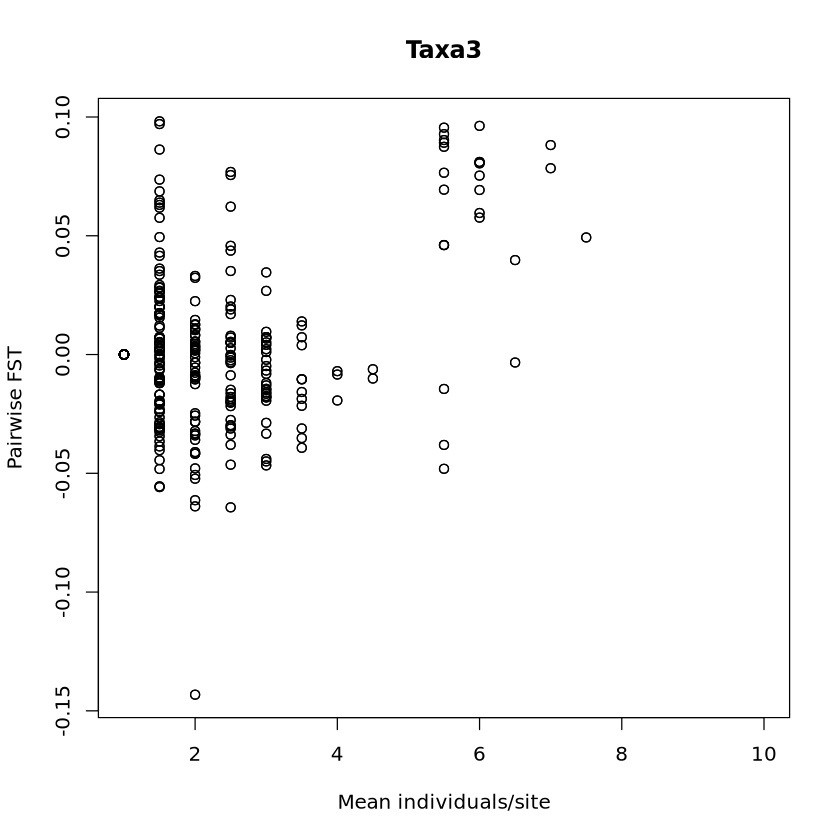

In [56]:
#Plot pairwise FSTs vs. individuals/site. This is a nice check to see if high FSTs are mostly or purely due to having few individuals per site
plot(fst3_long$mean_counts,fst3_long$fst,main="Taxa3",xlab="Mean individuals/site",ylab="Pairwise FST")

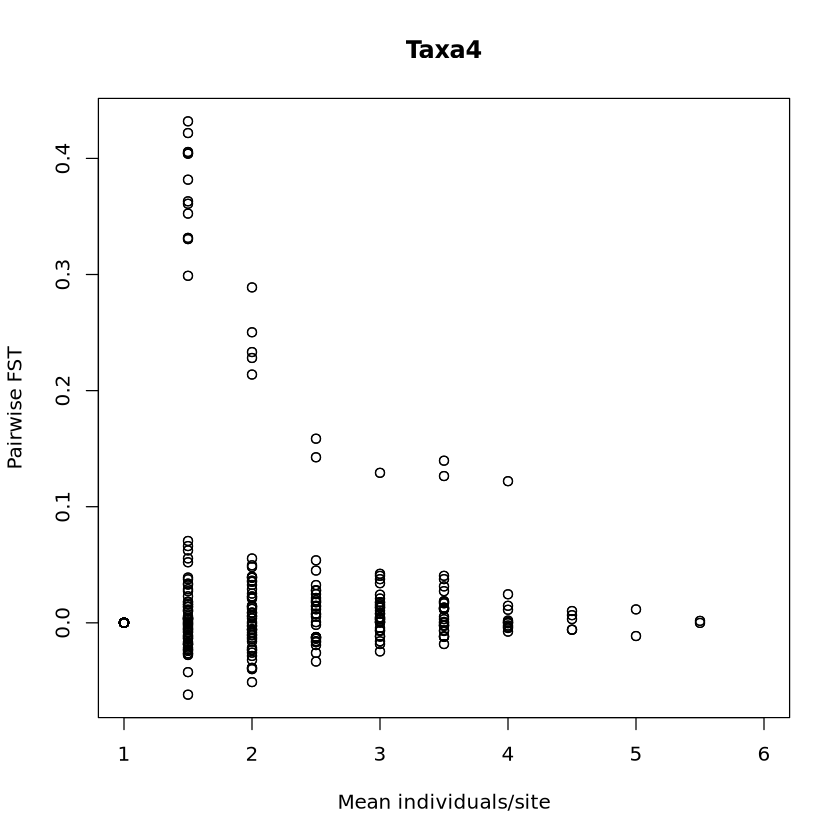

In [57]:
#Plot pairwise FSTs vs. individuals/site. This is a nice check to see if high FSTs are mostly or purely due to having few individuals per site
plot(fst4_long$mean_counts,fst4_long$fst,main="Taxa4",xlab="Mean individuals/site",ylab="Pairwise FST")

In [38]:
#Create matrix of FSTs only including populations where N>=2
fst_trim1<-fst_trim_by_N(fst1,inds_per_pop1,2)
fst_trim2<-fst_trim_by_N(fst2,inds_per_pop2,2)
fst_trim3<-fst_trim_by_N(fst3,inds_per_pop3,2)
fst_trim4<-fst_trim_by_N(fst4,inds_per_pop4,2)

fst_trim4b<-fst_trim_by_N(fst4b,inds_per_pop4,2)

fst_trim0<-fst_trim_by_N(fstall,inds_per_pop0,2)

In [39]:
#Create matrices of pairwise distances to correspond to sites with sufficiently high Ns.
dists_trim1<-dists1[rownames(dists1) %in% colnames(fst_trim1),colnames(dists1) %in% colnames(fst_trim1)]
dists_trim2<-dists2[rownames(dists2) %in% colnames(fst_trim2),colnames(dists2) %in% colnames(fst_trim2)]
dists_trim3<-dists3[rownames(dists3) %in% colnames(fst_trim3),colnames(dists3) %in% colnames(fst_trim3)]
dists_trim4<-dists4[rownames(dists4) %in% colnames(fst_trim4),colnames(dists4) %in% colnames(fst_trim4)]

dists_trim4b<-dists4b[rownames(dists4b) %in% colnames(fst_trim4b),colnames(dists4b) %in% colnames(fst_trim4b)]

dists_trim0<-dists0[rownames(dists0) %in% colnames(fst_trim0),colnames(dists0) %in% colnames(fst_trim0)]

In [40]:
#Take log of distances for Mantel tests
log_dists1_trim<-log(dists_trim1)
log_dists2_trim<-log(dists_trim2)
log_dists3_trim<-log(dists_trim3)
log_dists4_trim<-log(dists_trim4)

log_dists4b_trim<-log(dists_trim4)

log_dists0_trim<-log(dists_trim0)

In [41]:
#Convert wide form FSTs to linearized wide form FSTs for use in Mantel test, excluding low N sites
fst_lin1_trim<-as.data.frame(linear_fsts2(fst_trim1))
fst_lin2_trim<-as.data.frame(linear_fsts2(fst_trim2))
fst_lin3_trim<-as.data.frame(linear_fsts2(fst_trim3))
fst_lin4_trim<-as.data.frame(linear_fsts2(fst_trim4))

fst_lin4b_trim<-as.data.frame(linear_fsts2(fst_trim4b))

fst_lin0_trim<-as.data.frame(linear_fsts2(fst_trim0))

In [42]:
#Create dataframe of sites on Cebu island (exluding Camotes, which were originally labeled as Cebu)
Ceb_real <- sites[sites$LONGITUDE<124.25,3]

In [43]:
#Create matrices of FSTs from Cebu only, sites with 2+ individuals
fst_Cebu1_trim<-fst_lin1_trim[rownames(fst_lin1_trim) %in% Ceb_real, colnames(fst_lin1_trim) %in% Ceb_real]
fst_Cebu2_trim<-fst_lin2_trim[rownames(fst_lin2_trim) %in% Ceb_real, colnames(fst_lin2_trim) %in% Ceb_real]
fst_Cebu3_trim<-fst_lin3_trim[rownames(fst_lin3_trim) %in% Ceb_real, colnames(fst_lin3_trim) %in% Ceb_real]
fst_Cebu4_trim<-fst_lin4_trim[rownames(fst_lin4_trim) %in% Ceb_real, colnames(fst_lin4_trim) %in% Ceb_real]
fst_Cebu0_trim<-fst_lin0_trim[rownames(fst_lin0_trim) %in% Ceb_real, colnames(fst_lin0_trim) %in% Ceb_real]

fst_Cebu4b_trim<-fst_lin4b_trim[rownames(fst_lin4b_trim) %in% Ceb_real, colnames(fst_lin4b_trim) %in% Ceb_real]

In [44]:
#Create matrices of pairwise distances from Cebu only, sites with 2+ individuals
dists_Cebu1_trim<-dists_trim1[rownames(dists_trim1) %in% Ceb_real, colnames(dists_trim1) %in% Ceb_real]
dists_Cebu2_trim<-dists_trim2[rownames(dists_trim2) %in% Ceb_real, colnames(dists_trim2) %in% Ceb_real]
dists_Cebu3_trim<-dists_trim3[rownames(dists_trim3) %in% Ceb_real, colnames(dists_trim3) %in% Ceb_real]
dists_Cebu4_trim<-dists_trim4[rownames(dists_trim4) %in% Ceb_real, colnames(dists_trim4) %in% Ceb_real]
dists_Cebu0_trim<-dists_trim0[rownames(dists_trim0) %in% Ceb_real, colnames(dists_trim0) %in% Ceb_real]

dists_Cebu4b_trim<-dists_trim4b[rownames(dists_trim4b) %in% Ceb_real, colnames(dists_trim4b) %in% Ceb_real]

Run Mantel tests for each cryptic taxon. Note that these are Mantel tests for both Cebu and Leyte together!

In [44]:
#Mantel test, taxon 1
set.seed(42)
mantel(fst_Cebu1_trim,dists_Cebu1_trim)
mantel(fst_lin1_trim,log_dists1_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu1_trim, ydis = dists_Cebu1_trim) 

Mantel statistic r: -0.05811 
      Significance: 0.683 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.137 0.175 0.208 0.247 
Permutation: free
Number of permutations: 999



Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin1_trim, ydis = log_dists1_trim) 

Mantel statistic r: -0.03396 
      Significance: 0.679 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0984 0.1249 0.1443 0.1677 
Permutation: free
Number of permutations: 999


In [45]:
#Mantel tests, taxon 2
set.seed(42)
mantel(fst_Cebu2_trim,dists_Cebu2_trim)
mantel(fst_lin2_trim,log_dists2_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu2_trim, ydis = dists_Cebu2_trim) 

Mantel statistic r: -0.09537 
      Significance: 0.681 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.243 0.320 0.359 0.401 
Permutation: free
Number of permutations: 999



Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin2_trim, ydis = log_dists2_trim) 

Mantel statistic r: -0.07155 
      Significance: 0.71 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.149 0.193 0.230 0.262 
Permutation: free
Number of permutations: 999


In [46]:
#Mantel tests, taxon 3
set.seed(42)
mantel(fst_Cebu3_trim,dists_Cebu3_trim)
mantel(fst_lin3_trim,log_dists3_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu3_trim, ydis = dists_Cebu3_trim) 

Mantel statistic r: 0.09799 
      Significance: 0.273 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.299 0.379 0.434 0.518 
Permutation: free
Number of permutations: 999



Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin3_trim, ydis = log_dists3_trim) 

Mantel statistic r: 0.1378 
      Significance: 0.064 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.118 0.144 0.168 0.215 
Permutation: free
Number of permutations: 999


In [45]:
#Mantel tests, taxon 4
set.seed(42)
mantel(fst_Cebu4_trim,dists_Cebu4_trim)
mantel(fst_lin4_trim,log_dists4_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu4_trim, ydis = dists_Cebu4_trim) 

Mantel statistic r: 0.1799 
      Significance: 0.16 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.230 0.297 0.353 0.390 
Permutation: free
Number of permutations: 999



Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin4_trim, ydis = log_dists4_trim) 

Mantel statistic r: 0.1472 
      Significance: 0.174 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.198 0.312 0.334 0.349 
Permutation: free
Number of permutations: 999


In [48]:
#Mantel test, all taxa together
mantel(fst_lin0_trim,log_dists0_trim)
mantel(fst_Cebu0_trim,dists_Cebu0_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin0_trim, ydis = log_dists0_trim) 

Mantel statistic r: 0.1043 
      Significance: 0.048 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0806 0.1011 0.1264 0.1421 
Permutation: free
Number of permutations: 999



Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu0_trim, ydis = dists_Cebu0_trim) 

Mantel statistic r: 0.07011 
      Significance: 0.227 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.120 0.147 0.183 0.222 
Permutation: free
Number of permutations: 999


In [46]:
#Merge wide form linearized FSTs and wide form distances to long form dataframes of linearized FSTs and pairwise distances
merge1_trim<-fst_dist_join(fst_lin1_trim,dists1)
merge2_trim<-fst_dist_join(fst_lin2_trim,dists2)
merge3_trim<-fst_dist_join(fst_lin3_trim,dists3)
merge4_trim<-fst_dist_join(fst_lin4_trim,dists4)
merge0_trim<-fst_dist_join(fst_lin0_trim,dists0)

merge4b_trim<-fst_dist_join(fst_lin4b_trim,dists4b)

Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`


#Merge wide form linearized FSTs and wide form distances to long form dataframes of linearized FSTs and pairwise distances
#For FSTs with sites >1 individual
merge1_trim<-merge1[(merge1$SiteA %in% colnames(fst_lin0_trim) & merge1$SiteB %in% colnames(fst_lin0_trim)),]
merge2_trim<-merge2[(merge2$SiteA %in% colnames(fst_lin0_trim) & merge2$SiteB %in% colnames(fst_lin0_trim)),]
merge3_trim<-merge3[(merge3$SiteA %in% colnames(fst_lin0_trim) & merge3$SiteB %in% colnames(fst_lin0_trim)),]
merge4_trim<-merge4[(merge4$SiteA %in% colnames(fst_lin0_trim) & merge4$SiteB %in% colnames(fst_lin0_trim)),]

merge4b_trim<-merge4b[(merge4b$SiteA %in% colnames(fst_lin0_trim) & merge4b$SiteB %in% colnames(fst_lin0_trim)),]

In [47]:
#Create datasets with Cebu only
merge1_Ceb<-fst_dist_join(fst_Cebu1_trim,dists_Cebu1_trim)
merge2_Ceb<-fst_dist_join(fst_Cebu2_trim,dists_Cebu2_trim)
merge3_Ceb<-fst_dist_join(fst_Cebu3_trim,dists_Cebu3_trim)
merge4_Ceb<-fst_dist_join(fst_Cebu4_trim,dists_Cebu4_trim)

merge0_Ceb<-fst_dist_join(fst_Cebu0_trim,dists_Cebu0_trim)

merge4b_Ceb<-fst_dist_join(fst_Cebu4b_trim,dists_Cebu4b_trim)

Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`


In [48]:
#Linear models 2D, linearized FST ~ log distance
summary(lm(Lin_FST ~ log(Distance_m),data=merge1_trim))
summary(lm(Lin_FST ~ log(Distance_m),data=merge2_trim))
summary(lm(Lin_FST ~ log(Distance_m),data=merge3_trim))
summary(lm(Lin_FST ~ log(Distance_m),data=merge4_trim))


Call:
lm(formula = Lin_FST ~ log(Distance_m), data = merge1_trim)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018236 -0.004277 -0.000246  0.004106  0.027268 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)
(Intercept)      0.0031422  0.0059776   0.526    0.600
log(Distance_m) -0.0003115  0.0005310  -0.587    0.558

Residual standard error: 0.006805 on 298 degrees of freedom
Multiple R-squared:  0.001153,	Adjusted R-squared:  -0.002198 
F-statistic: 0.3441 on 1 and 298 DF,  p-value: 0.5579



Call:
lm(formula = Lin_FST ~ log(Distance_m), data = merge2_trim)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0214860 -0.0036669  0.0004162  0.0037084  0.0160469 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)
(Intercept)      0.0043301  0.0083179   0.521    0.604
log(Distance_m) -0.0005399  0.0007416  -0.728    0.468

Residual standard error: 0.006722 on 103 degrees of freedom
Multiple R-squared:  0.00512,	Adjusted R-squared:  -0.004539 
F-statistic: 0.5301 on 1 and 103 DF,  p-value: 0.4682



Call:
lm(formula = Lin_FST ~ log(Distance_m), data = merge3_trim)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.051080 -0.019207 -0.006205  0.005041  0.098649 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)
(Intercept)     -0.059811   0.049254  -1.214    0.228
log(Distance_m)  0.005635   0.004294   1.312    0.193

Residual standard error: 0.03256 on 89 degrees of freedom
Multiple R-squared:  0.01898,	Adjusted R-squared:  0.007956 
F-statistic: 1.722 on 1 and 89 DF,  p-value: 0.1928



Call:
lm(formula = Lin_FST ~ log(Distance_m), data = merge4_trim)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.06544 -0.04261 -0.03031 -0.01169  0.36346 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)
(Intercept)     -0.16316    0.15397  -1.060    0.293
log(Distance_m)  0.01772    0.01366   1.297    0.198

Residual standard error: 0.08761 on 76 degrees of freedom
Multiple R-squared:  0.02166,	Adjusted R-squared:  0.00879 
F-statistic: 1.683 on 1 and 76 DF,  p-value: 0.1985


In [49]:
#Calculate distances, 1D
merge1_Ceb_trim<-merge1_trim[(merge1_trim$SiteA %in% Ceb_real) & (merge1_trim$SiteB %in% Ceb_real),]
merge2_Ceb_trim<-merge2_trim[(merge2_trim$SiteA %in% Ceb_real) & (merge2_trim$SiteB %in% Ceb_real),]
merge3_Ceb_trim<-merge3_trim[(merge3_trim$SiteA %in% Ceb_real) & (merge3_trim$SiteB %in% Ceb_real),]
merge4_Ceb_trim<-merge4_trim[(merge4_trim$SiteA %in% Ceb_real) & (merge4_trim$SiteB %in% Ceb_real),]

merge1_Ceb_trim$Dist_km<-(merge1_Ceb_trim$Distance_m/1000)
merge2_Ceb_trim$Dist_km<-(merge2_Ceb_trim$Distance_m/1000)
merge3_Ceb_trim$Dist_km<-(merge3_Ceb_trim$Distance_m/1000)
merge4_Ceb_trim$Dist_km<-(merge4_Ceb_trim$Distance_m/1000)

merge4b_Ceb_trim<-merge4b_trim[(merge4b_trim$SiteA %in% Ceb_real) & (merge4b_trim$SiteB %in% Ceb_real),]

In [50]:
#Calculate log distances, 2D
merge1_trim$Dist_log<-log(merge1_trim$Distance_m)
merge2_trim$Dist_log<-log(merge2_trim$Distance_m)
merge3_trim$Dist_log<-log(merge3_trim$Distance_m)
merge4_trim$Dist_log<-log(merge4_trim$Distance_m)

merge1_trim$Dist_log_km<-log(merge1_trim$Distance_m/1000)
merge2_trim$Dist_log_km<-log(merge2_trim$Distance_m/1000)
merge3_trim$Dist_log_km<-log(merge3_trim$Distance_m/1000)
merge4_trim$Dist_log_km<-log(merge4_trim$Distance_m/1000)

merge4b_trim$Dist_log<-log(merge4b_trim$Distance_m)

In [51]:
#Calculate standard errors of IBD slopes in one and two dimensions for each taxon. 
se1_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_trim))$coefficients[2,2]
se2_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_trim))$coefficients[2,2]
se3_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_trim))$coefficients[2,2]
se4_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_trim))$coefficients[2,2]

se1_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge1_Ceb_trim))$coefficients[2,2]
se2_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge2_Ceb_trim))$coefficients[2,2]
se3_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge3_Ceb_trim))$coefficients[2,2]
se4_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge4_Ceb_trim))$coefficients[2,2]

se4b_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge4b_trim))$coefficients[2,2]
se4b_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge4b_Ceb_trim))$coefficients[2,2]

In [52]:
#Calculate point estimates of slopes in one and two dimensions
m1_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_trim))$coefficients[2,1]
m2_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_trim))$coefficients[2,1]
m3_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_trim))$coefficients[2,1]
m4_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_trim))$coefficients[2,1]

m1_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge1_Ceb_trim))$coefficients[2,1]
m2_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge2_Ceb_trim))$coefficients[2,1]
m3_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge3_Ceb_trim))$coefficients[2,1]
m4_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge4_Ceb_trim))$coefficients[2,1]

m4b_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge4b_trim))$coefficients[2,1]
m4b_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge4b_Ceb_trim))$coefficients[2,1]

In [53]:
#Calculate distribution of slopes
set.seed(42)
m1s_trim<-rnorm(1000, mean = m1_trim, sd = se1_trim)
m2s_trim<-rnorm(1000, mean = m2_trim, sd = se2_trim)
m3s_trim<-rnorm(1000, mean = m3_trim, sd = se3_trim)
m4s_trim<-rnorm(1000, mean = m4_trim, sd = se4_trim)

m1_Cs_trim<-rnorm(1000, mean = m1_Ceb_trim, sd = se1_Ceb_trim)
m2_Cs_trim<-rnorm(1000, mean = m2_Ceb_trim, sd = se2_Ceb_trim)
m3_Cs_trim<-rnorm(1000, mean = m3_Ceb_trim, sd = se3_Ceb_trim)
m4_Cs_trim<-rnorm(1000, mean = m4_Ceb_trim, sd = se4_Ceb_trim)

m4bs_trim<-rnorm(1000, mean = m4b_trim, sd = se4b_trim)
m4b_Cs_trim<-rnorm(1000, mean = m4b_Ceb_trim, sd = se4b_Ceb_trim)

In [54]:
#Calculate distribution of slopes with km (for plotting confidence intervals)
set.seed(42)
m1_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge1_trim))$coefficients[2,1]
m2_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge2_trim))$coefficients[2,1]
m3_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge3_trim))$coefficients[2,1]
m4_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge4_trim))$coefficients[2,1]

se1_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge1_trim))$coefficients[2,2]
se2_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge2_trim))$coefficients[2,2]
se3_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge3_trim))$coefficients[2,2]
se4_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge4_trim))$coefficients[2,2]

m1s_km_trim<-rnorm(1000, mean = m1_km_trim, sd = se1_km_trim)
m2s_km_trim<-rnorm(1000, mean = m2_km_trim, sd = se2_km_trim)
m3s_km_trim<-rnorm(1000, mean = m3_km_trim, sd = se3_km_trim)
m4s_km_trim<-rnorm(1000, mean = m4_km_trim, sd = se4_km_trim)

In [55]:
#Calculate distribution of slopes in 1D with km (for plotting confidence intervals)
set.seed(42)
m1_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge1_Ceb_trim))$coefficients[2,1]
m2_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge2_Ceb_trim))$coefficients[2,1]
m3_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge3_Ceb_trim))$coefficients[2,1]
m4_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge4_Ceb_trim))$coefficients[2,1]

se1_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge1_Ceb_trim))$coefficients[2,2]
se2_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge2_Ceb_trim))$coefficients[2,2]
se3_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge3_Ceb_trim))$coefficients[2,2]
se4_km_Ceb_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge4_Ceb_trim))$coefficients[2,2]

m1s_km_Ceb_trim<-rnorm(1000, mean = m1_km_Ceb_trim, sd = se1_km_Ceb_trim)
m2s_km_Ceb_trim<-rnorm(1000, mean = m2_km_Ceb_trim, sd = se2_km_Ceb_trim)
m3s_km_Ceb_trim<-rnorm(1000, mean = m3_km_Ceb_trim, sd = se3_km_Ceb_trim)
m4s_km_Ceb_trim<-rnorm(1000, mean = m4_km_Ceb_trim, sd = se4_km_Ceb_trim)

In [56]:
#Summarize percent of IBD slopes greater than zero, 1D
print('taxon 1')
m1_Ceb_trim
se1_Ceb_trim
table(m1_Cs_trim>0)

print('taxon 2')
m2_Ceb_trim
se2_Ceb_trim
table(m2_Cs_trim>0)

print('taxon 3')
m3_Ceb_trim
se3_Ceb_trim
table(m3_Cs_trim>0)

print('taxon 4')
m4_Ceb_trim
se4_Ceb_trim
table(m4_Cs_trim>0)

print('taxon 4, no weirdos')
m4b_Ceb_trim
se4b_Ceb_trim
table(m4b_Cs_trim>0)

[1] "taxon 1"


[1] -8.387844e-09

[1] 1.172751e-08


FALSE  TRUE 
  765   235 

[1] "taxon 2"


...


FALSE  TRUE 
  126   874 

[1] "taxon 4, no weirdos"


[1] -1.248291e-07

[1] 7.392156e-08


FALSE  TRUE 
  950    50 

In [57]:
#Summarize percent of IBD slopes greater than zero, 2D
print('taxon 1')
m1_trim
se1_trim
table(m1s_trim>0)

print('taxon 2')
m2_trim
se2_trim
table(m2s_trim>0)

print('taxon 3')
m3_trim
se3_trim
table(m3s_trim>0)

print('taxon 4')
m4_trim
se4_trim
table(m4s_trim>0)

print('taxon 4, no weirdos')
m4b_trim
quantile(m4bs_trim,probs=c(0.025,0.975))
table(m4bs_trim>0)

[1] "taxon 1"


[1] -0.0003114772

[1] 0.0005309818


FALSE  TRUE 
  721   279 

[1] "taxon 2"


...


FALSE  TRUE 
   98   902 

[1] "taxon 4, no weirdos"


[1] 0.001560031

2.5%        97.5% 
-0.004708754  0.008218101


FALSE  TRUE 
  316   684 

`geom_smooth()` using formula = 'y ~ x'
Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'


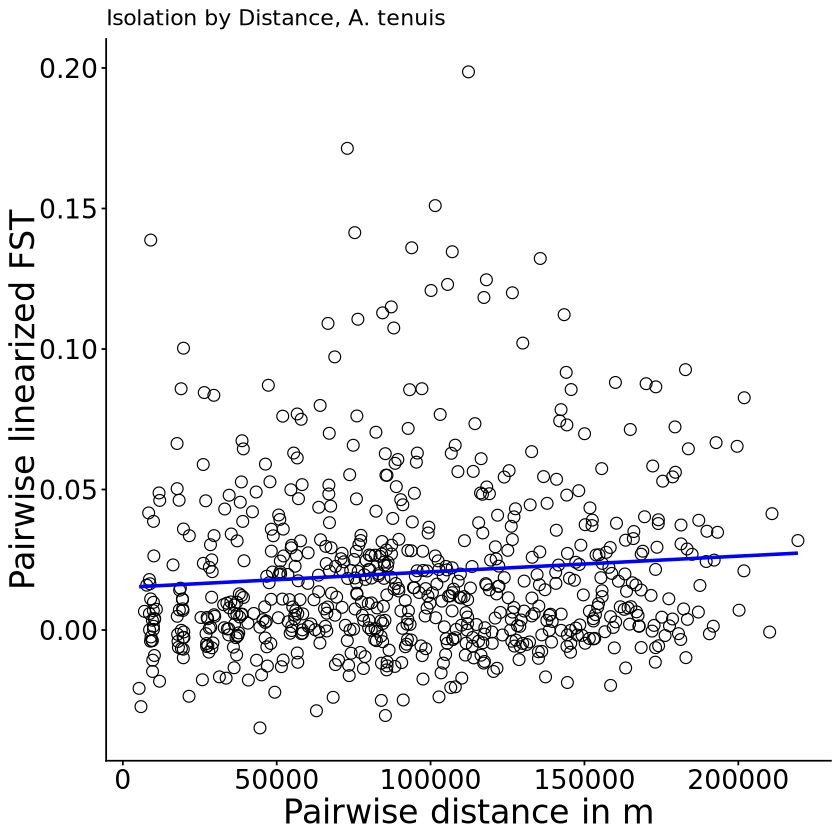

In [64]:
#Plot IBD curve of all cryptic taxa together
ggplot(merge0_trim, aes(x=Distance_m, y=Lin_FST)) + geom_point(shape=1,size=3)+
theme_classic()+
theme(axis.text.x = element_text(size = 16),axis.text.y = element_text(size = 16),axis.title.x = element_text(size = 20),axis.title.y = element_text(size = 20))+
ggtitle('Isolation by Distance, A. tenuis')+
geom_smooth(method=lm, color="blue",se=FALSE)+
labs(x="Pairwise distance in m", y = "Pairwise linearized FST")
ggsave('Acropora_IBD_all.png',dpi = 1200)

FIGURE PLOTTING 2D ALL SITES N>0

FIGURE PLOTTING 1D AND 2D SITES N>1

In [57]:
#Create little dataframes justfor figure plotting
figdat1_trim<-join_for_fig(merge1_trim,fst1_long)
figdat2_trim<-join_for_fig(merge2_trim,fst2_long)
figdat3_trim<-join_for_fig(merge3_trim,fst3_long)
figdat4_trim<-join_for_fig(merge4_trim,fst4_long)

In [67]:
#Calculate confidence intervals around slopes for plotting
slope_min1_trim<-quantile(m1s_km_trim,probs=c(0.025))
slope_max1_trim<-quantile(m1s_km_trim,probs=c(0.975))
intercept1_trim<-lm(Lin_FST ~ log(Distance_km), data = figdat1_trim)$coefficients[1]
value_mins1_trim<-intercept1_trim+slope_min1_trim*log(figdat1_trim$Distance_km)
value_maxs1_trim<-intercept1_trim+slope_max1_trim*log(figdat1_trim$Distance_km)
value_meds1_trim<-intercept1_trim+m1_km_trim*log(figdat1_trim$Distance_km)

slope_min2_trim<-quantile(m2s_km_trim,probs=c(0.025))
slope_max2_trim<-quantile(m2s_km_trim,probs=c(0.975))
intercept2_trim<-lm(Lin_FST ~ log(Distance_km), data = figdat2_trim)$coefficients[1]
value_mins2_trim<-intercept2_trim+slope_min2_trim*log(figdat2_trim$Distance_km)
value_maxs2_trim<-intercept2_trim+slope_max2_trim*log(figdat2_trim$Distance_km)
value_meds2_trim<-intercept2_trim+m2_km_trim*log(figdat2_trim$Distance_km)

slope_min3_trim<-quantile(m3s_km_trim,probs=c(0.025))
slope_max3_trim<-quantile(m3s_km_trim,probs=c(0.975))
intercept3_trim<-lm(Lin_FST ~ log(Distance_km), data = figdat3_trim)$coefficients[1]
value_mins3_trim<-intercept3_trim+slope_min3_trim*log(figdat3_trim$Distance_km)
value_maxs3_trim<-intercept3_trim+slope_max3_trim*log(figdat3_trim$Distance_km)
value_meds3_trim<-intercept3_trim+m3_km_trim*log(figdat3_trim$Distance_km)

slope_min4_trim<-quantile(m4s_km_trim,probs=c(0.025))
slope_max4_trim<-quantile(m4s_km_trim,probs=c(0.975))
intercept4_trim<-lm(Lin_FST ~ log(Distance_km), data = figdat4_trim)$coefficients[1]
value_mins4_trim<-intercept4_trim+slope_min4_trim*log(figdat4_trim$Distance_km)
value_maxs4_trim<-intercept4_trim+slope_max4_trim*log(figdat4_trim$Distance_km)
value_meds4_trim<-intercept4_trim+m4_km_trim*log(figdat4_trim$Distance_km)

In [59]:
#Create little dataframes justfor figure plotting, Cebu only
figdat1_Cebu<-figdat1_trim[(figdat1_trim$SiteA %in% Ceb_real & figdat1_trim$SiteB %in% Ceb_real),]
figdat2_Cebu<-figdat2_trim[(figdat2_trim$SiteA %in% Ceb_real & figdat2_trim$SiteB %in% Ceb_real),]
figdat3_Cebu<-figdat3_trim[(figdat3_trim$SiteA %in% Ceb_real & figdat3_trim$SiteB %in% Ceb_real),]
figdat4_Cebu<-figdat4_trim[(figdat4_trim$SiteA %in% Ceb_real & figdat4_trim$SiteB %in% Ceb_real),]

In [65]:
#Calculate confidence intervals around slopes for plotting, Cebu only
slope_min1_Cebu<-quantile(m1s_km_Ceb_trim,probs=c(0.025))
slope_max1_Cebu<-quantile(m1s_km_Ceb_trim,probs=c(0.975))
intercept1_Cebu<-lm(Lin_FST ~ Distance_km, data = figdat1_Cebu)$coefficients[1]
value_mins_Cebu1_trim<-intercept1_Cebu+slope_min1_Cebu*figdat1_Cebu$Distance_km
value_maxs_Cebu1_trim<-intercept1_Cebu+slope_max1_Cebu*figdat1_Cebu$Distance_km
value_meds_Cebu1_trim<-intercept1_Cebu+m1_km_Ceb_trim*figdat1_Cebu$Distance_km

slope_min2_Cebu<-quantile(m2s_km_Ceb_trim,probs=c(0.025))
slope_max2_Cebu<-quantile(m2s_km_Ceb_trim,probs=c(0.975))
intercept2_Cebu<-lm(Lin_FST ~ Distance_km, data = figdat2_Cebu)$coefficients[1]
value_mins_Cebu2_trim<-intercept2_Cebu+slope_min2_Cebu*figdat2_Cebu$Distance_km
value_maxs_Cebu2_trim<-intercept2_Cebu+slope_max2_Cebu*figdat2_Cebu$Distance_km
value_meds_Cebu2_trim<-intercept2_Cebu+m2_km_Ceb_trim*figdat2_Cebu$Distance_km

slope_min3_Cebu<-quantile(m3s_km_Ceb_trim,probs=c(0.025))
slope_max3_Cebu<-quantile(m3s_km_Ceb_trim,probs=c(0.975))
intercept3_Cebu<-lm(Lin_FST ~ Distance_km, data = figdat3_Cebu)$coefficients[1]
value_mins_Cebu3_trim<-intercept3_Cebu+slope_min3_Cebu*figdat3_Cebu$Distance_km
value_maxs_Cebu3_trim<-intercept3_Cebu+slope_max3_Cebu*figdat3_Cebu$Distance_km
value_meds_Cebu3_trim<-intercept1_Cebu+m3_km_Ceb_trim*figdat3_Cebu$Distance_km

slope_min4_Cebu<-quantile(m4s_km_Ceb_trim,probs=c(0.025))
slope_max4_Cebu<-quantile(m4s_km_Ceb_trim,probs=c(0.975))
intercept4_Cebu<-lm(Lin_FST ~ Distance_km, data = figdat4_Cebu)$coefficients[1]
value_mins_Cebu4_trim<-intercept4_Cebu+slope_min4_Cebu*figdat4_Cebu$Distance_km
value_maxs_Cebu4_trim<-intercept4_Cebu+slope_max4_Cebu*figdat4_Cebu$Distance_km
value_meds_Cebu4_trim<-intercept4_Cebu+m4_km_Ceb_trim*figdat4_Cebu$Distance_km

In [61]:
intercept3_trim

(Intercept) 
 -0.0208859

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


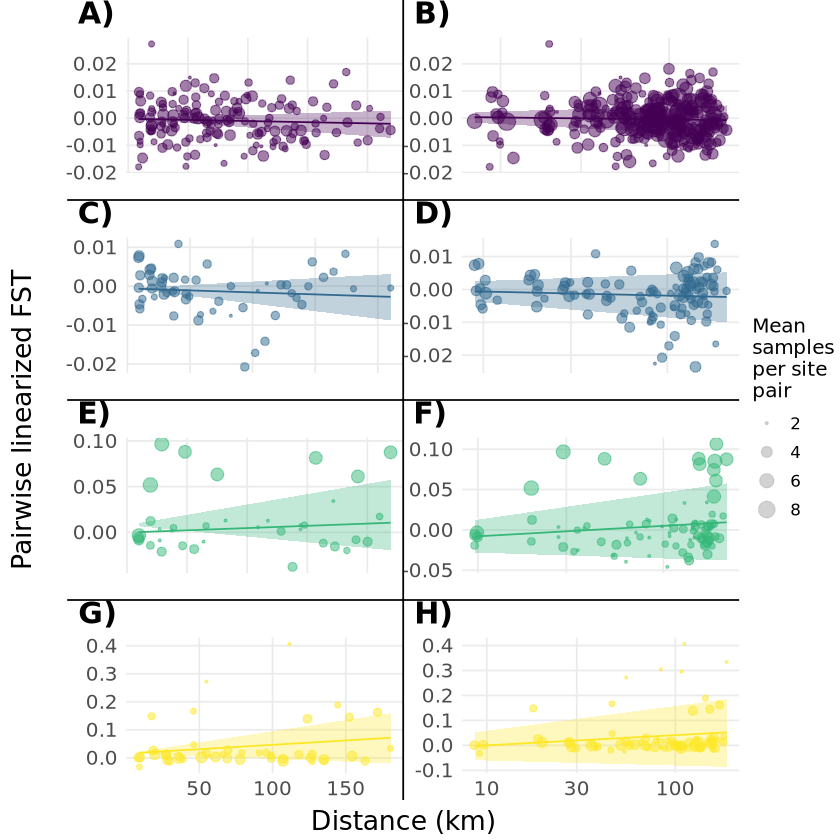

In [76]:
#Make figure of isolation in each taxon 2D
fst_plot<-function(data, color, fsts_lin, dists, ribbon_meds, ribbon_mins, ribbon_maxs, log_scale=TRUE){
  pl<-ggplot(data, aes(x = as.numeric(Distance_km), y = Lin_FST)) +
  geom_point(aes(size = mean_counts), col=color, alpha=0.5) +
  geom_ribbon(aes(ymin = ribbon_mins, ymax = ribbon_maxs), fill=color, alpha = 0.3)+
  geom_line(aes(y=ribbon_meds),col=color)+
  scale_size_continuous(name = "Mean samples per site pair", range = c(0.5, 0.5*max(data$mean_counts))) +
    theme_minimal() +
    theme(axis.title.x = element_blank(),
          axis.title.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),
          plot.margin = unit(c(0.8, 0, 0, 0),"cm"),
          panel.grid.minor = element_blank(),
          legend.position = "none")
  
  # Add log scale only if requested
  if(log_scale) {
    pl <- pl + scale_x_continuous(trans='log10')
  }
  
  return(pl) 
}

# Create the eight plots - SWAPPED LEFT AND RIGHT
# Row 1 (A and B) - Taxa 1, no x-axis labels
plot_a <- fst_plot(figdat1_Cebu, "#440154FF", fsts_lin=fst_Cebu1_trim, dists=dists_Cebu1_trim, ribbon_meds=value_meds_Cebu1_trim, ribbon_mins=value_mins_Cebu1_trim, ribbon_maxs=value_maxs_Cebu1_trim, log_scale=FALSE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

plot_b <- fst_plot(figdat1_trim, "#440154FF", fsts_lin=fst_lin1_trim, dists=log_dists1_trim, ribbon_meds=value_meds1_trim, ribbon_mins=value_mins1_trim, ribbon_maxs=value_maxs1_trim, log_scale=TRUE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

# Row 2 (C and D) - Taxa 2, no x-axis labels
plot_c <- fst_plot(figdat2_Cebu, "#31688EFF", fsts_lin=fst_Cebu2_trim, dists=dists_Cebu2_trim, ribbon_meds=value_meds_Cebu2_trim,ribbon_mins=value_mins_Cebu2_trim, ribbon_maxs=value_maxs_Cebu2_trim, log_scale=FALSE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

plot_d <- fst_plot(figdat2_trim, "#31688EFF", fsts_lin=fst_lin2_trim, dists=log_dists2_trim,ribbon_meds=value_meds2_trim, ribbon_mins=value_mins2_trim, ribbon_maxs=value_maxs2_trim, log_scale=TRUE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

# Row 3 (E and F) - Taxa 3, no x-axis labels
plot_e <- fst_plot(figdat3_Cebu, "#35B779FF", fsts_lin=fst_Cebu3_trim, dists=dists_Cebu3_trim,ribbon_meds=value_meds_Cebu3_trim, ribbon_mins=value_mins_Cebu3_trim, ribbon_maxs=value_maxs_Cebu3_trim, log_scale=FALSE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

plot_f <- fst_plot(figdat3_trim, "#35B779FF", fsts_lin=fst_lin3_trim, dists=log_dists3_trim, ribbon_meds=value_meds3_trim,ribbon_mins=value_mins3_trim, ribbon_maxs=value_maxs3_trim, log_scale=TRUE) +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.title.x = element_blank())

# Row 4 (G and H) - Taxa 4, with x-axis labels
plot_g <- fst_plot(figdat4_Cebu, "#FDE725FF", fsts_lin=fst_Cebu4_trim, dists=dists_Cebu4_trim, ribbon_meds=value_meds_Cebu4_trim,ribbon_mins=value_mins_Cebu4_trim, ribbon_maxs=value_maxs_Cebu4_trim, log_scale=FALSE) +
  coord_cartesian(clip = "off") +
  theme(plot.margin = unit(c(0.2, 0, 0, 0), "cm"))

plot_h <- fst_plot(figdat4_trim, "#FDE725FF", fsts_lin=fst_lin4_trim, dists=log_dists4_trim,ribbon_meds=value_meds4_trim, ribbon_mins=value_mins4_trim, ribbon_maxs=value_maxs4_trim, log_scale=TRUE)

# Combine plots using cowplot - 4 rows, 2 columns
combined_plot <- plot_grid(
  plot_a, plot_b,
  plot_c, plot_d,
  plot_e, plot_f,
  plot_g, plot_h,
  ncol = 2, 
  nrow = 4,
  labels = c("A)", "B)", "C)", "D)", "E)", "F)", "G)", "H)"),
  label_size = 18,
  label_colour = "black",
  label_x = 0.01,
  label_y = 0.86,
  align = "hv",
  rel_widths = c(1, 1),
  rel_heights = c(1, 1, 1, 1),
  hjust = -0.2,
  vjust = -0.2
)

# Add dividing lines between panels
combined_plot_with_lines <- ggdraw(combined_plot) +
  # Vertical line down the middle
  draw_line(x = c(0.5, 0.5), y = c(0, 1), color = "black", linewidth = 0.5) +
  # Horizontal lines
  draw_line(x = c(0, 1), y = c(0.75, 0.75), color = "black", linewidth = 0.5) +
  draw_line(x = c(0, 1), y = c(0.5, 0.5), color = "black", linewidth = 0.5) +
  draw_line(x = c(0, 1), y = c(0.25, 0.25), color = "black", linewidth = 0.5)

# Create a shared x-axis label for the bottom
x_axis_label <- ggdraw() + 
  draw_label("Distance (km)", 
             x = 0.5, y = 0.5, 
             size = 16,
             hjust = 0.5)

# Combine the plots with the shared x-axis label
plot_with_xlabel <- plot_grid(
  combined_plot_with_lines,
  x_axis_label,
  ncol = 1,
  rel_heights = c(1, 0.05)
)

# Create a sample plot just to extract the legend - using one of the actual datasets
legend_plot <- ggplot(figdat1_trim, aes(x = as.numeric(Distance_km), y = Lin_FST, size = mean_counts)) +
  geom_point(col="gray", alpha = 0.7) +
  scale_size_continuous(name = "Mean \nsamples\nper site \npair", 
                       range = c(0.5, 0.5*max(figdat1_trim$mean_counts)),
                       breaks = pretty(figdat1_trim$mean_counts, n = 4)) +
  theme_minimal() +
  theme(legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10))

# Extract just the legend
legend <- get_legend(legend_plot)

# Add the legend to the right side
plot_with_all_elements <- plot_grid(
  plot_with_xlabel,
  legend,
  ncol = 2,
  rel_widths = c(1, 0.15)
)

# Add shared y-axis label
final_plot <- ggdraw() +
  draw_plot(plot_with_all_elements, x = 0.08, y = 0, width = 0.92, height = 1) +
  draw_label("Pairwise linearized FST", 
             x = 0.025, y = 0.5,  
             angle = 90, 
             size = 16,
             hjust = 0.5)

# Display the combined plot
print(final_plot)

# Save the plot
ggsave("combined_ibd_plot_8panel.jpg", final_plot, width = 7, height = 10, dpi = 800)